<a href="https://colab.research.google.com/github/europecodingschool/ECS---VB---YZ---08.26/blob/main/VB_YZ_Ders_9_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

In [ ]:
df = pd.read_csv("/content/yakit_tuketimi.csv")

In [ ]:
df.head()

,Hiz_kmh,Yakit_L_100km
0,20,8.90
1,25,8.13
2,25,8.14
3,25,8.39
4,25,8.35


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Hiz_kmh        120 non-null    int64  
 1   Yakit_L_100km  120 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 2.0 KB


In [ ]:
df.shape

(120, 2)

In [ ]:
#dependent and independent feature
X = df[["Hiz_kmh"]]
y = df["Yakit_L_100km"]

In [ ]:
#train - test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=42)

In [ ]:
X_train

,Hiz_kmh
24,45
78,100
22,45
96,115
56,75
...,...
106,120
14,35
92,110
51,75


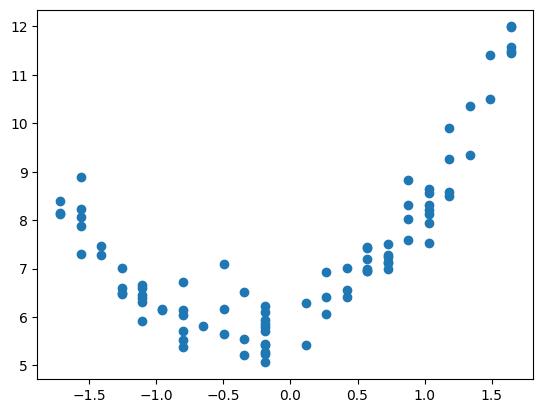

In [ ]:
plt.scatter(X_train,y_train)
plt.show() # datamıza bakıyoruz.

In [ ]:
#scaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
regression = LinearRegression()

In [ ]:
regression.fit(X_train, y_train)

LinearRegression()

In [ ]:
#prediction

In [ ]:
y_pred = regression.predict(X_test)

In [ ]:
y_pred

array([6.87616299, 7.01851001, 5.7373868 , 7.16085704, 6.3067749 ,
       7.44555108, 7.73024513, 6.02208085, 6.87616299, 8.44198025,
       6.16442787, 7.30320406, 6.02208085, 6.59146894, 8.01493918,
       8.1572862 , 8.58432727, 5.59503978, 8.01493918, 8.44198025,
       7.44555108, 7.01851001, 6.59146894, 7.73024513, 6.87616299,
       6.02208085, 6.02208085, 8.7266743 , 7.87259215, 8.29963323])

In [ ]:
score = r2_score(y_test, y_pred)
print(score) #r2 skoru lineer regresyonda istediğimiz seviyede olmadı. Bu nedenle polinom regresyon üzerinden ilerlemeye karar verdik. Daatamızın dağılımıda bunu gösterdi.

-0.022767725331579225


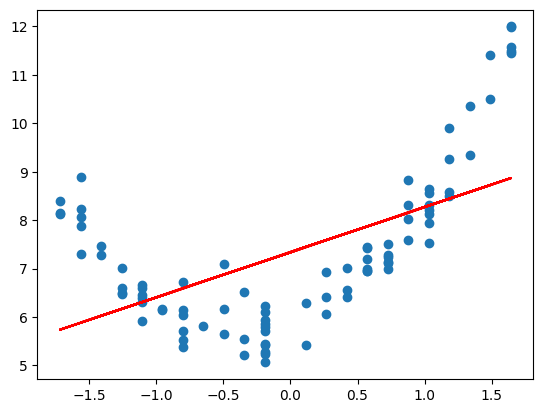

In [ ]:
plt.scatter(X_train,y_train)
plt.plot(X_train, regression.predict(X_train), color='r')
plt.show()

In [ ]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
regression = LinearRegression()
regression.fit(X_train_poly,y_train)

LinearRegression()

In [ ]:
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.8781339657606306


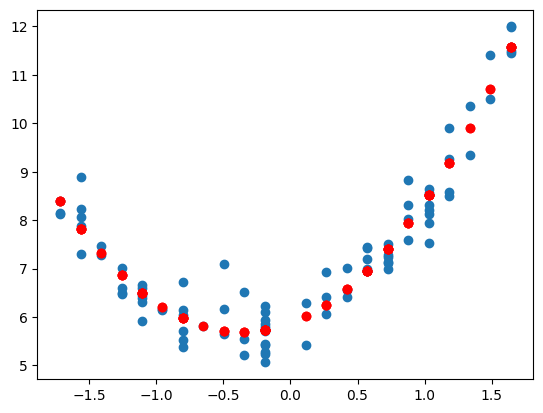

In [ ]:
plt.scatter(X_train, y_train)
plt.scatter(X_train, regression.predict(X_train_poly), color='r')
plt.show()

In [ ]:
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
regression = LinearRegression()
regression.fit(X_train_poly,y_train)

LinearRegression()

In [ ]:
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.8772242967279763


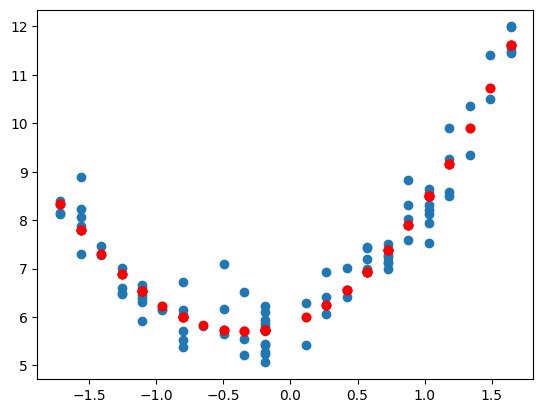

In [ ]:
plt.scatter(X_train, y_train)
plt.scatter(X_train, regression.predict(X_train_poly), color='r')
plt.show()